# One cluster in scan mode, with spectroscopic post-processing

Scan mode is redMaPPer's zscan, run at given positions (X-ray or SZ candidates). At the input
position, λ(z) and the likelihood LNLAMLIKE(z) are computed on Δz = 0.005 steps from
z = 0.05 to 1.0 in a fixed 0.5 h⁻¹Mpc aperture, and ZMAX is the likelihood peak. Starting
from ZMAX, z_λ is refined with the percolation aperture (r0 = 1 h⁻¹Mpc, β = 0.2). An
optical centre is then chosen within 0.4 h⁻¹Mpc of the input position (wcen centring), and
λ and z_λ are recomputed there (LAMBDA_OPT, Z_LAMBDA_OPT). The spectroscopic
post-processing adds the cluster redshift and velocity dispersion from the members' Z_SPEC.
The target is the SZ cluster ACT-CL J0012.9-0857, given by its position only. The notebook
scan itself takes under a minute on a GPU; reading the randoms files takes most of the runtime.

## Setup and parameters

At CC-IN2P3 the defaults read the DR11 data system (sweeps, randoms, and the calibration and
catalogues of the production run); elsewhere set `REMA_DR11_DIR`, `REMA_PRODUCTS` (or
`REMA_CALIB`) and `REMA_WORK`. The ACT redshift is used only for the comparisons at the end.

In [1]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")   # before importing jax

import dataclasses
import logging
import re
import sys
import time
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.table import Table
from matplotlib.colors import LinearSegmentedColormap

# Persistent compilation cache, shared with the rema command line.
jax.config.update("jax_compilation_cache_dir",
                  os.environ.get("JAX_COMPILATION_CACHE_DIR") or os.path.expanduser("~/.cache/rema/jax"))
jax.config.update("jax_persistent_cache_min_compile_time_secs", 1.0)

# Paths: the environment variables, else the DR11 data system at CC-IN2P3 when /sps is mounted
# (the Jupyter kernels there do not read ~/.bashrc), else a local copy with the same layout.
CC = Path("/sps/lsst/datasets/desi/legacysurveys")
LS_DIR = Path(os.environ.get("LEGACYSURVEY_DIR", CC if CC.exists() else Path.home() / "data" / "legacysurvey"))
DR11 = Path(os.environ.get("REMA_DR11_DIR", LS_DIR / "dr11" / "south"))
# The DR11 south production run (rema 0.2.0) next to the sweeps: two parts that meet at RA 0 and
# 240 deg and at Dec -85 deg, with one calibration.
PRODUCTS = Path(os.environ.get("REMA_PRODUCTS", DR11 / "rema"))
RUNS = [PRODUCTS / "rema_dr11_v0.2.0_ra0-240", PRODUCTS / "rema_dr11_v0.2.0_ra240-360"]
CALIB = Path(os.environ.get("REMA_CALIB", RUNS[0] / "calib" / "calib.fits"))
EXAMPLES = Path(os.environ.get("REMA_WORK", PRODUCTS / "notebooks"))   # what the notebooks write
RANDOMS = sorted((DR11 / "randoms").glob("randoms-south-1-*.fits"))     # every randoms file present


def read_all_randoms(cfg, box):
    """The randoms of every file in RANDOMS inside ``box``, and their density per deg²."""
    from rema.sky.maps import read_randoms

    parts = [read_randoms(f, cfg, box) for f in RANDOMS]
    return {k: np.concatenate([q[k] for q in parts]) for k in parts[0]}, cfg.mask.randoms_density * len(parts)

import rema
from rema.calibration import Calibration
from rema.io.legacy import ingest
from rema.io.tables import write_catalog
from rema.model.cosmo import CosmoTable
from rema.modes import specpost
from rema.modes.common import Region
from rema.modes.scan import run_scan
from rema.sky.maps import build_footprint, read_randoms
from rema.sky.regions import Box, sweeps_overlapping

WORK = EXAMPLES / "scan"
WORK.mkdir(parents=True, exist_ok=True)

NAME = "ACT-CL J0012.9-0857"
RA, DEC = 3.23333, -8.95419
Z_ACT = 0.352          # ACT DR5 (spectroscopic), for the comparison at the end only

print(f"rema {rema.__version__}, jax {jax.__version__}, devices: {jax.devices()}")

rema 0.2.0, jax 0.11.2, devices: [CudaDevice(id=0)]


In [2]:
class StageSummaries(logging.Filter):
    """Drop rema's per-batch progress lines; keep the stage summaries."""

    progress = re.compile(r"seeds \(K=|round \d+,")

    def filter(self, record):
        return not self.progress.search(record.getMessage())


logging.basicConfig(level=logging.INFO, format="%(asctime)s %(name)s %(message)s",
                    datefmt="%H:%M:%S", stream=sys.stdout, force=True)
for handler in logging.getLogger().handlers:
    handler.addFilter(StageSummaries())

# Figures: hairline grid, a one-hue sequential ramp, three categorical colours.
plt.rcParams.update({"figure.dpi": 100, "font.size": 9, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
                     "legend.frameon": False})
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#a3a29d"
RAMP = LinearSegmentedColormap.from_list(
    "ramp", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])


def outline(ax, box, **kw):
    """Draw a Box (or each box of a BoxUnion) on RA/Dec axes."""
    for b in box.boxes:
        ax.plot([b.ra_min, b.ra_max, b.ra_max, b.ra_min, b.ra_min],
                [b.dec_min, b.dec_min, b.dec_max, b.dec_max, b.dec_min], **kw)


def label_candidates(ax, x, y, p_cen, r=26):
    """Circle the centre candidates and label them with P_CEN.

    Call after the axis limits are set. Labels point away from the plot centre and are
    turned, when needed, so that they do not overlap.
    """
    ax.scatter(x, y, s=160, facecolor="none", edgecolor=ORANGE, lw=1.5, label="centre candidates")
    ax.apply_aspect()
    to_pt = 72 / ax.figure.dpi
    cx, cy = ax.transData.transform((0, 0)) * to_pt
    placed = []
    for xk, yk, pk in zip(x, y, p_cen):
        px, py = ax.transData.transform((xk, yk)) * to_pt
        base = np.arctan2(py - cy, px - cx) if np.hypot(px - cx, py - cy) > 3 else np.pi / 4
        for turn in (0, 0.6, -0.6, 1.2, -1.2, 1.8, -1.8, 2.4, -2.4, np.pi):
            dx, dy = r * np.cos(base + turn), r * np.sin(base + turn)
            if all(np.hypot(px + dx - qx, py + dy - qy) > 18 for qx, qy in placed):
                break
        placed.append((px + dx, py + dy))
        ax.annotate(f"{pk:.2f}", (xk, yk), xytext=(dx, dy), textcoords="offset points",
                    ha="center", va="center", fontsize=8,
                    arrowprops=dict(arrowstyle="-", color=GREY, lw=0.6, shrinkA=0, shrinkB=7))


T = {}   # wall-clock time of each step [s]

## The region around the target

The galaxies and the footprint are needed only around the target: the box
`Box(RA, RA, DEC, DEC).buffered(1.0)`, about 4 deg². The largest aperture is the
neighbour radius of the percolation aperture, 1.2 r0 3^β = 1.5 h⁻¹Mpc, plus the 0.4 h⁻¹Mpc
of the centre search. At the lowest redshift of the scan, z = 0.05, these 1.9 h⁻¹Mpc
subtend 0.77°, so a 1° buffer is enough. The configuration comes from the calibration
file.

`read_randoms` scans the whole 23 GB randoms file and keeps the randoms in the box. Here the
file was in the page cache; read from disk it takes about a minute and dominates the
runtime of a single scan. On an HPC, footprints are made once per region and read back
with `Footprint.read`.

In [3]:
cal = Calibration.read(CALIB)
cfg = cal.config

box = Box(RA, RA, DEC, DEC).buffered(1.0)
cosmo = CosmoTable.create(cfg.cosmology.Omega_m, cfg.cosmology.h)
rc = cfg.richness
r_max = rc.maxrad_factor * rc.percolation.r0 * 3 ** rc.percolation.beta + cfg.centering.scan_maxrad
z_min = cfg.scan.zrange[0]
print(f"box RA {box.ra_min:.3f} to {box.ra_max:.3f}, Dec {box.dec_min:.3f} to {box.dec_max:.3f}: "
      f"{box.area_deg2():.2f} deg²")
print(f"largest aperture {r_max:.2f} h⁻¹Mpc = {r_max / float(cosmo.mpc_per_deg(z_min)):.2f}° "
      f"at z = {z_min}")

sweeps = sweeps_overlapping(box, DR11 / "sweep" / "11.0")
t0 = time.perf_counter()
gal = ingest(sweeps, WORK / "galaxies.fits", cfg, box=box)
T["ingest"] = time.perf_counter() - t0
print(f"{gal['ID'].size:,} galaxies, {np.sum(gal['ZSPEC'] > 0):,} with ZSPEC > 0, "
      f"in {T['ingest']:.0f} s")

t0 = time.perf_counter()
rnd, density = read_all_randoms(cfg, box)
fp = build_footprint(rnd, cfg, box=box, density=density)
fp.write(WORK / "footprint.fits")
T["footprint"] = time.perf_counter() - t0
print(f"footprint: {rnd['RA'].size:,} randoms, unmasked area {fp.area_deg2():.2f} deg², "
      f"in {T['footprint']:.0f} s")

box RA 2.221 to 4.246, Dec -9.954 to -7.954: 4.00 deg²
largest aperture 1.89 h⁻¹Mpc = 0.77° at z = 0.05


09:28:37 rema.io.legacy sweep-000m010-005m005.fits: 146473 galaxies


146,473 galaxies, 1,810 with ZSPEC > 0, in 21 s


footprint: 40,122 randoms, unmasked area 3.85 deg², in 920 s


## Calibration and zred

The DR11 griz calibration of the production run, fitted on RA 160–180° and 190–210°,
Dec −10° to 10°: red sequence, zred correction, χ² and zred backgrounds, z_λ correction and
the wcen centring model. `Region.build` computes zred for every galaxy.

In [4]:
print(f"{CALIB.name}: rema {cal.meta['REMAVER']}, bands {cal.meta['BANDS']}, reference "
      f"{cal.meta['REFBAND']}, χ² mode {cal.meta['CHI2MODE']}, wcen from {cal.meta['NWCEN']} clusters")

t0 = time.perf_counter()
reg = Region.build(gal, cal.rs, cfg, footprint=fp, zredcorr=cal.zredcorr, bkg=cal.bkg,
                   zlcorr=cal.zlcorr, zbkg=cal.zbkg, wcen_params=cal.wcen)
T["zred"] = time.perf_counter() - t0
method = reg.centering_method()
print(f"zred for {reg.gal['ZRED'].size:,} galaxies in {T['zred']:.1f} s; centring: {method}")

calib.fits: rema 0.2.0, bands g,r,i,z, reference z, χ² mode lupt, wcen from 8650 clusters


zred for 146,473 galaxies in 11.2 s; centring: wcen


## Scan and spectroscopic post-processing

`run_scan` takes lists of positions (and identifiers), processed in batches of 128. The
spectroscopic post-processing uses the members of the fit at the input position (PMEM ≥
0.01). The output is written as `rema scan` writes it.

In [5]:
t0 = time.perf_counter()
cat, mem = run_scan(reg, [RA], [DEC], ids=[0])
T["scan"] = time.perf_counter() - t0
nz = int(round((cfg.scan.zrange[1] - cfg.scan.zrange[0]) / cfg.scan.zstep)) + 1
assert cat["Z_STEPS"].shape == cat["LAMBDA_STEPS"].shape == cat["LIKELIHOOD_STEPS"].shape == (1, nz)
print(f"scan in {T['scan']:.1f} s: λ(z) at {nz} redshifts, z = {cat['Z_STEPS'][0, 0]:.3f} "
      f"to {cat['Z_STEPS'][0, -1]:.3f}; {mem['ID'].size} members")

t0 = time.perf_counter()
cat, mem = specpost.process(cat, mem, **dataclasses.asdict(cfg.spec))
T["specpost"] = time.perf_counter() - t0
path = write_catalog(WORK / "scan.fits", cat, mem, cfg, {"MODE": "scan", "CENTRING": method})
print(f"wrote {path}")

scan in 34.9 s: λ(z) at 191 redshifts, z = 0.050 to 1.000; 150 members


wrote /sps/lsst/datasets/desi/legacysurveys/dr11/south/rema/notebooks/scan/scan.fits


## Results

LMAX is λ at ZMAX in the 0.5 h⁻¹Mpc scan aperture. LAMBDA, Z_LAMBDA, SCALEVAL and MASKFRAC
are those of the percolation aperture at the input position, and the …_OPT columns those at
the optical centre. The offset in h⁻¹Mpc is at Z_LAMBDA_OPT.

In [6]:
cl = {k: v[0] for k, v in cat.items()}
off = SkyCoord(RA, DEC, unit="deg").separation(SkyCoord(cl["RA_OPT"], cl["DEC_OPT"], unit="deg"))
off_mpc = off.deg * reg.mpc_per_deg_np(cl["Z_LAMBDA_OPT"])
rows = [
    ("input position (RA, Dec)", f"{cl['RA']:.5f}, {cl['DEC']:.5f}"),
    ("ZMAX, LMAX", f"{cl['ZMAX']:.3f}, {cl['LMAX']:.1f}" + (" (grid edge)" if cl["ZMAX_EDGE"] else "")),
    ("Z_LAMBDA", f"{cl['Z_LAMBDA']:.4f} ± {cl['Z_LAMBDA_E']:.4f}"),
    ("LAMBDA", f"{cl['LAMBDA']:.1f} ± {cl['LAMBDA_E']:.1f}"),
    ("RA_OPT, DEC_OPT", f"{cl['RA_OPT']:.5f}, {cl['DEC_OPT']:.5f}"),
    ("offset of the optical centre", f"{off.arcsec:.1f}″ = {off_mpc:.3f} h⁻¹Mpc"),
    ("Z_LAMBDA_OPT", f"{cl['Z_LAMBDA_OPT']:.4f} ± {cl['Z_LAMBDA_OPT_E']:.4f}"),
    ("LAMBDA_OPT", f"{cl['LAMBDA_OPT']:.1f} ± {cl['LAMBDA_OPT_E']:.1f}"),
    ("R_LAMBDA", f"{cl['R_LAMBDA']:.3f} h⁻¹Mpc"),
    ("SCALEVAL, MASKFRAC", f"{cl['SCALEVAL']:.3f}, {cl['MASKFRAC']:.3f}"),
    ("P_CEN[0], NCENT_GOOD", f"{cl['P_CEN'][0]:.3f}, {cl['NCENT_GOOD']}"),
    ("NSPEC, N_MEMBERS", f"{cl['NSPEC']}, {cl['N_MEMBERS']}"),
    ("SPEC_Z_BOOT", f"{cl['SPEC_Z_BOOT']:.4f} ± {cl['SPEC_ZERR_BOOT']:.4f}"),
    ("VDISP", f"{cl['VDISP']:.0f} ± {cl['VDISP_ERR']:.0f} km/s ({cl['VDISP_TYPE']})"),
    ("BEST_Z", f"{cl['BEST_Z']:.4f} ({cl['BEST_Z_TYPE']})"),
]
width = max(len(label) for label, _ in rows)
for label, value in rows:
    print(f"{label:<{width}}  {value}")

print(f"\nagainst z_ACT = {Z_ACT}:")
for key in ("ZMAX", "Z_LAMBDA_OPT", "SPEC_Z_BOOT"):
    print(f"  ({key} − z_ACT)/(1 + z_ACT) = {(cl[key] - Z_ACT) / (1 + Z_ACT):+.4f}")

# Every spectroscopic redshift near the target between 0.30 and 0.42, members or not.
near = SkyCoord(gal["RA"], gal["DEC"], unit="deg").separation(SkyCoord(RA, DEC, unit="deg")).arcmin < 6
zs = np.sort(gal["ZSPEC"][near & (gal["ZSPEC"] > 0.30) & (gal["ZSPEC"] < 0.42)])
print(f"{zs.size} galaxies within 6′ with 0.30 < ZSPEC < 0.42: ZSPEC {zs.min():.4f} to "
      f"{zs.max():.4f}, {np.sum(np.abs(zs - Z_ACT) < 0.005)} within 0.005 of z_ACT")

input position (RA, Dec)      3.23333, -8.95419
ZMAX, LMAX                    0.395, 34.1
Z_LAMBDA                      0.3399 ± 0.0043
LAMBDA                        96.6 ± 4.5
RA_OPT, DEC_OPT               3.24043, -8.97486
offset of the optical centre  78.6″ = 0.266 h⁻¹Mpc
Z_LAMBDA_OPT                  0.3382 ± 0.0044
LAMBDA_OPT                    87.4 ± 4.2
R_LAMBDA                      0.993 h⁻¹Mpc
SCALEVAL, MASKFRAC            1.038, 0.037
P_CEN[0], NCENT_GOOD          0.791, 5
NSPEC, N_MEMBERS              16, 14
SPEC_Z_BOOT                   0.3364 ± 0.0016
VDISP                         847 ± 246 km/s (gapper)
BEST_Z                        0.3364 (spec_z_boot)

against z_ACT = 0.352:
  (ZMAX − z_ACT)/(1 + z_ACT) = +0.0318
  (Z_LAMBDA_OPT − z_ACT)/(1 + z_ACT) = -0.0102
  (SPEC_Z_BOOT − z_ACT)/(1 + z_ACT) = -0.0115
17 galaxies within 6′ with 0.30 < ZSPEC < 0.42: ZSPEC 0.3270 to 0.3408, 0 within 0.005 of z_ACT


z_λ at the optical centre (0.338) agrees with the spectroscopic redshift of the 14 kept
members (0.336 ± 0.002). z_λ and SPEC_Z_BOOT lie 0.010–0.012 (1 + z) below the ACT
redshift (ZMAX, on the second maximum of the scan, lies 0.03 above), and no spectroscopic redshift within 6′ is near it: the 17 between 0.30 and
0.42 span 0.327–0.341. The optical centre is 79″ (0.27 h⁻¹Mpc) from the SZ position, with
the P_CEN printed above. Blind mode centres this cluster on its brightest member, 0.49 h⁻¹Mpc from the
SZ position, outside the 0.4 h⁻¹Mpc search radius of scan mode (see the blind notebook).

## Figures

λ(z) and LNLAMLIKE(z) along the scan, and p(z) of the refined z_λ at the input position.
LNLAMLIKE is undefined where λ ≤ 0; those steps are left out. Both curves have two
maxima, at z = 0.340 and 0.395. The second is slightly higher in λ (34.1 against 32.1) and in
the likelihood (40.0 against 39.6), so ZMAX = 0.395; the refinement of z_λ in the percolation
aperture, which starts from ZMAX, converges to the first (z_λ = 0.340), where the
spectroscopic members are.

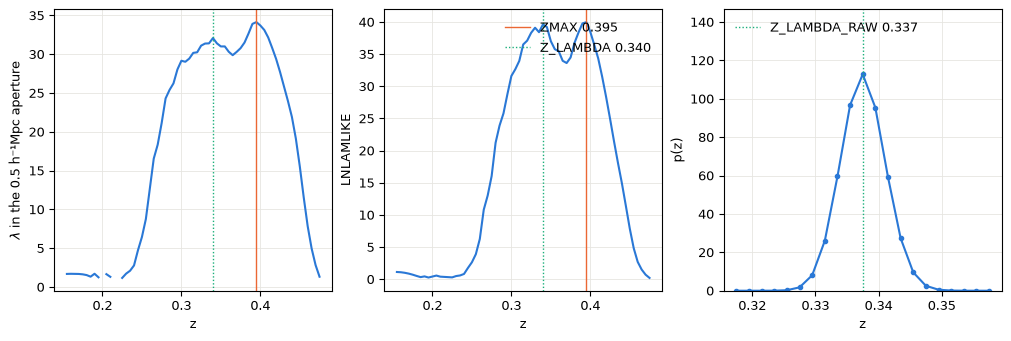

In [7]:
z, lz, like = cl["Z_STEPS"], cl["LAMBDA_STEPS"], cl["LIKELIHOOD_STEPS"]
ok = (lz > 0) & np.isfinite(like)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.3), constrained_layout=True)
axes[0].plot(z, np.where(lz > 0, lz, np.nan), color=BLUE, lw=1.5)
axes[1].plot(z[ok], like[ok], color=BLUE, lw=1.5)
for ax in axes[:2]:
    ax.axvline(cl["ZMAX"], color=ORANGE, lw=1, label=f"ZMAX {cl['ZMAX']:.3f}")
    ax.axvline(cl["Z_LAMBDA"], color=AQUA, lw=1, ls=(0, (1, 1.5)), label=f"Z_LAMBDA {cl['Z_LAMBDA']:.3f}")
    ax.set_xlabel("z")
axes[0].set_ylabel(r"$\lambda$ in the 0.5 h⁻¹Mpc aperture")
axes[1].set_ylabel("LNLAMLIKE")
axes[1].legend(loc="upper right")
axes[2].plot(cl["PZBINS"], cl["PZ"], color=BLUE, lw=1.5, marker="o", ms=3)
axes[2].axvline(cl["Z_LAMBDA_RAW"], color=AQUA, lw=1, ls=(0, (1, 1.5)),
                label=f"Z_LAMBDA_RAW {cl['Z_LAMBDA_RAW']:.3f}")
axes[2].set(xlabel="z", ylabel="p(z)", ylim=(0, 1.3 * cl["PZ"].max()))
axes[2].legend(loc="upper left")
plt.show()

Left: the members on the sky around the input position, coloured by PMEM, with symbol
size by z-band magnitude. The circles have radius R_LAMBDA and 0.4 h⁻¹Mpc (the centre
search). The centre candidates are labelled with P_CEN; the optical centre is the most
probable one. Right: the rest-frame velocities of the members with a spectroscopic redshift,
relative to SPEC_Z, with a Gaussian of width VDISP.

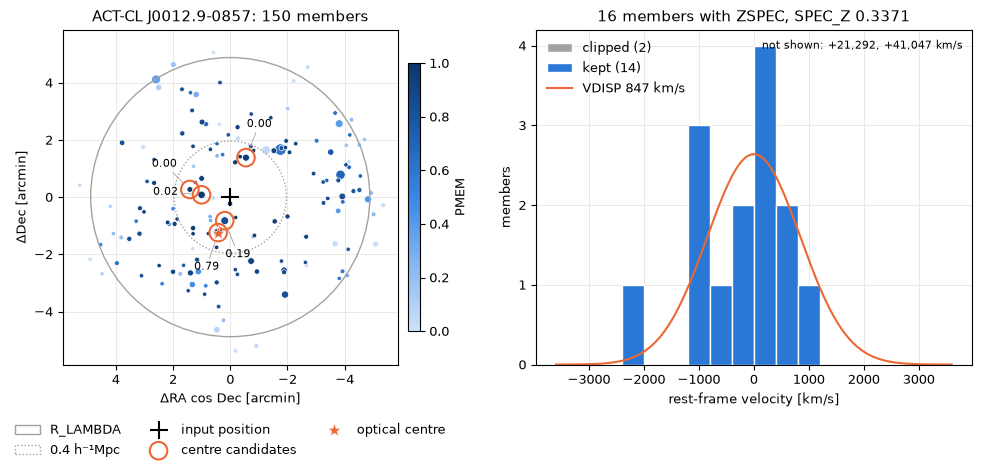

In [8]:
cosd = np.cos(np.radians(DEC))


def offsets(ra, dec):
    """Offsets from the input position [arcmin]."""
    return (np.asarray(ra) - RA) * cosd * 60, (np.asarray(dec) - DEC) * 60


dx, dy = offsets(mem["RA"], mem["DEC"])
pm, mag = mem["PMEM"], mem["REFMAG"]
o = np.argsort(pm)
arcmin_per_mpc = 60 / reg.mpc_per_deg_np(cl["Z_LAMBDA"])
r_lam = cl["R_LAMBDA"] * arcmin_per_mpc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.6), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1.15, 1]})
sc = ax1.scatter(dx[o], dy[o], c=pm[o], cmap=RAMP, vmin=0, vmax=1,
                 s=8 + 60 * 10 ** (-0.4 * (mag[o] - mag.min())), edgecolor="white", lw=0.5)
ax1.add_patch(plt.Circle((0, 0), r_lam, fill=False, color=GREY, lw=1, label="R_LAMBDA"))
ax1.add_patch(plt.Circle((0, 0), cfg.centering.scan_maxrad * arcmin_per_mpc, fill=False,
                         color=GREY, lw=1, ls=(0, (1, 1.5)), label="0.4 h⁻¹Mpc"))
ax1.scatter(0, 0, marker="+", s=150, color="black", lw=1.5, label="input position")
okc = cl["ID_CENT"] >= 0
cx, cy = offsets(cl["RA_CENT"][okc], cl["DEC_CENT"][okc])
ax1.set(xlim=(1.2 * r_lam, -1.2 * r_lam), ylim=(-1.2 * r_lam, 1.2 * r_lam),
        xlabel="ΔRA cos Dec [arcmin]", ylabel="ΔDec [arcmin]", title=f"{NAME}: {pm.size} members")
ax1.set_aspect("equal")
label_candidates(ax1, cx, cy, cl["P_CEN"][okc])
ox, oy = offsets(cl["RA_OPT"], cl["DEC_OPT"])
ax1.scatter(ox, oy, marker="*", s=110, color=ORANGE, edgecolor="white", lw=0.5, zorder=4,
            label="optical centre")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3)
fig.colorbar(sc, cax=ax1.inset_axes([1.03, 0.1, 0.035, 0.8]), label="PMEM")

vel, kept = mem["VEL"], mem["ISMEMBER_SPEC"]
has = np.isfinite(vel)
sig = cl["VDISP"]
if np.isfinite(sig):
    width = max(100.0, 100.0 * round(sig / 200))       # about σ/2, in steps of 100 km/s
    vmax = width * np.ceil(4 * sig / width)
    bins = np.arange(-vmax, vmax + width / 2, width)
    ax2.hist(vel[has & ~kept], bins=bins, color=GREY, edgecolor="white", lw=1,
             label=f"clipped ({np.sum(has & ~kept)})")
    ax2.hist(vel[kept], bins=bins, color=BLUE, edgecolor="white", lw=1, label=f"kept ({kept.sum()})")
    vv = np.linspace(-vmax, vmax, 300)
    norm = kept.sum() * width / (np.sqrt(2 * np.pi) * sig)
    ax2.plot(vv, norm * np.exp(-0.5 * (vv / sig) ** 2), color=ORANGE, lw=1.5,
             label=f"VDISP {sig:.0f} km/s")
    out = has & (np.abs(vel) > vmax)
    if out.any():
        ax2.text(0.98, 0.97, "not shown: " + ", ".join(f"{v:+,.0f}" for v in vel[out]) + " km/s",
                 transform=ax2.transAxes, ha="right", va="top", fontsize=8)
    ax2.yaxis.get_major_locator().set_params(integer=True)
    ax2.set(xlabel="rest-frame velocity [km/s]", ylabel="members",
            title=f"{has.sum()} members with ZSPEC, SPEC_Z {cl['SPEC_Z']:.4f}")
    ax2.legend(loc="upper left")
else:
    ax2.text(0.5, 0.5, "fewer than 3 spectroscopic members", ha="center", transform=ax2.transAxes)
plt.show()

## Members

The ten members with the highest PMEM. R is the distance from the input position in
h⁻¹Mpc; ZSPEC is −1 without a spectroscopic redshift.

In [9]:
top = np.argsort(-mem["PMEM"])[:10]
members = Table({k: mem[k][top] for k in ("REFMAG", "ZRED", "ZSPEC", "R", "PMEM")})
for col, fmt in (("REFMAG", ".2f"), ("ZRED", ".3f"), ("ZSPEC", ".4f"), ("R", ".3f"), ("PMEM", ".3f")):
    members[col].format = fmt
members.pprint(max_width=-1)

REFMAG  ZRED  ZSPEC    R    PMEM
------ ----- ------- ----- -----
 18.96 0.343 -1.0000 0.046 0.989
 19.14 0.348 -1.0000 0.249 0.976
 17.71 0.353  0.3387 0.204 0.974
 20.16 0.353 -1.0000 0.370 0.968
 19.98 0.363 -1.0000 0.368 0.966
 18.57 0.368 -1.0000 0.291 0.963
 19.83 0.308 -1.0000 0.295 0.961
 18.96 0.350 -1.0000 0.359 0.960
 19.26 0.390 -1.0000 0.254 0.958
 17.89 0.366  0.3383 0.301 0.956


## The production catalogue

The DR11 south production run found clusters blind over the whole footprint with the same
calibration (merged catalogues on the data system, `PRODUCTS`). The cell lists the
production clusters centred within 3′ of the input position: scan mode, which starts from
the position, and blind mode, which starts from its own seeds, should find the same system.

In [10]:
from rema.io.tables import read_catalog

target = SkyCoord(RA, DEC, unit="deg")
found = False
for run in RUNS:
    f = run / "clusters_dr11.fits"
    if not f.exists():
        print(f"{run.name}: not available yet")
        continue
    pc, _, _ = read_catalog(f, members=False)
    sep = SkyCoord(pc["RA"], pc["DEC"], unit="deg").separation(target).arcmin
    near = np.flatnonzero(sep < 3)
    if near.size == 0:
        continue
    found = True
    near = near[np.argsort(sep[near])]
    tab = Table({"PART": [run.name] * near.size, "SEP_ARCMIN": sep[near],
                 **{k: np.asarray(pc[k])[near] for k in ("LAMBDA", "Z_LAMBDA", "SPEC_Z_BOOT", "N_MEMBERS")}})
    for col, fmt in (("SEP_ARCMIN", ".2f"), ("LAMBDA", ".1f"), ("Z_LAMBDA", ".4f"), ("SPEC_Z_BOOT", ".4f")):
        tab[col].format = fmt
    tab.pprint(max_width=-1)
print(f"scan mode: LAMBDA_OPT {cl['LAMBDA_OPT']:.1f}, Z_LAMBDA_OPT {cl['Z_LAMBDA_OPT']:.4f}" if found
      else "no production cluster within 3′")

          PART           SEP_ARCMIN LAMBDA Z_LAMBDA SPEC_Z_BOOT N_MEMBERS
------------------------ ---------- ------ -------- ----------- ---------
rema_dr11_v0.2.0_ra0-240       0.85    3.7   0.3424      0.3368         5
rema_dr11_v0.2.0_ra0-240       2.05    6.9   0.8675         nan         0
rema_dr11_v0.2.0_ra0-240       2.42  107.0   0.3401      0.3366        15
rema_dr11_v0.2.0_ra0-240       2.90    4.2   0.7902         nan         0
rema_dr11_v0.2.0_ra240-360: not available yet
scan mode: LAMBDA_OPT 87.4, Z_LAMBDA_OPT 0.3382


## Runtimes

In [11]:
for step, sec in T.items():
    print(f"{step:10s} {sec:6.1f} s")
print(f"{'total':10s} {sum(T.values()):6.1f} s on {jax.devices()[0].device_kind}")

ingest       21.0 s
footprint   919.6 s
zred         11.2 s
scan         34.9 s
specpost      1.8 s
total       988.6 s on Tesla V100-SXM2-32GB


## The same run from the command line

The positions file is a FITS table with columns RA, DEC and an identifier:

In [12]:
positions = Table({"RA": [RA], "DEC": [DEC], "NAME": [NAME]})
positions.write(WORK / "positions.fits", overwrite=True)
print(positions)

   RA     DEC            NAME       
------- -------- -------------------
3.23333 -8.95419 ACT-CL J0012.9-0857


```bash
rema ingest DR11/sweep/11.0/sweep-000m010-005m005.fits --box 2.221 4.246 -9.955 -7.954 \
     --out galaxies.fits
rema maps DR11/randoms/randoms-south-1-0.fits --box 2.221 4.246 -9.955 -7.954 --out footprint.fits
rema scan --galaxies galaxies.fits --calib CALIB --footprint footprint.fits \
     --positions positions.fits --id-col NAME --specpost --out scan.fits
```

MEM_MATCH_ID is then the NAME column. `rema scan` uses the calibration's configuration
unless `--config` is given. As for blind mode, pass `--config` to `rema ingest` and
`rema maps` when the calibration was made with a non-default configuration, and set
`JAX_PLATFORMS=cuda` to run on a GPU.